# 04 — Autoencoder Anomaly Detector

Trains a tabular autoencoder on **BENIGN traffic only**. At inference time the
reconstruction MSE is compared to a threshold (99th percentile on validation
benign) — anything above is flagged anomalous, possibly a zero-day attack the
MLP has never seen.


In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from src import config as cfg
from src.models import build_autoencoder, reconstruction_error
sns.set_theme(style="whitegrid")


## 1. Load benign-only training and full validation set

In [2]:
train = pd.read_csv(cfg.PROCESSED_DIR / "train.csv")
val   = pd.read_csv(cfg.PROCESSED_DIR / "val.csv")

scaler = joblib.load(cfg.SCALER_FILE)
with open(cfg.FEATURE_NAMES_FILE) as f: feature_names = json.load(f)

train_benign = train[train[cfg.LABEL_COL] == "BENIGN"]
print("Benign train rows:", len(train_benign))

X_train = scaler.transform(train_benign[feature_names].astype(np.float32).values)
X_val   = scaler.transform(val[feature_names].astype(np.float32).values)
y_val_is_attack = (val[cfg.LABEL_COL] != "BENIGN").astype(int).values


Benign train rows: 1589924


## 2. Build the autoencoder

In [3]:
ae = build_autoencoder(
    input_dim=X_train.shape[1],
    encoder_units=cfg.AE_CONFIG["encoder_units"],
    latent_dim=cfg.AE_CONFIG["latent_dim"],
    learning_rate=cfg.AE_CONFIG["learning_rate"],
)
ae.summary()


2026-05-10 01:30:58,065 [WARNING] tensorflow: TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


Model: "smarttids_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_0 (Dense)                   │ (None, 64)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_0 (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 77)             │         5,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,541 (60.71 KB)

 Trainable params: 15,541 (60.71 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Train

In [4]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=cfg.AE_CONFIG["patience"],
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
]

# Train AE on benign only — internal val_split keeps things honest.
history = ae.fit(
    X_train, X_train,
    epochs=cfg.AE_CONFIG["epochs"],
    batch_size=cfg.AE_CONFIG["batch_size"],
    validation_split=0.1,
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/50
2795/2795 - 13s - 4ms/step - loss: 0.2470 - mae: 0.1279 - val_loss: 0.2914 - val_mae: 0.0894 - learning_rate: 0.0010
Epoch 2/50
2795/2795 - 9s - 3ms/step - loss: 0.1266 - mae: 0.0909 - val_loss: 0.2649 - val_mae: 0.0720 - learning_rate: 0.0010
Epoch 3/50
2795/2795 - 9s - 3ms/step - loss: 0.0988 - mae: 0.0795 - val_loss: 0.2597 - val_mae: 0.0673 - learning_rate: 0.0010
Epoch 4/50
2795/2795 - 11s - 4ms/step - loss: 0.0691 - mae: 0.0640 - val_loss: 0.1799 - val_mae: 0.0551 - learning_rate: 0.0010
Epoch 5/50
2795/2795 - 11s - 4ms/step - loss: 0.0710 - mae: 0.0607 - val_loss: 0.1251 - val_mae: 0.0763 - learning_rate: 0.0010
Epoch 6/50
2795/2795 - 11s - 4ms/step - loss: 0.0591 - mae: 0.0547 - val_loss: 0.0996 - val_mae: 0.0531 - learning_rate: 0.0010
Epoch 7/50
2795/2795 - 10s - 4ms/step - loss: 0.0643 - mae: 0.0524 - val_loss: 0.0892 - val_mae: 0.0452 - learning_rate: 0.0010
Epoch 8/50
2795/2795 - 10s - 4ms/step - loss: 0.0568 - mae: 0.0501 - val_loss: 0.0553 - val_mae: 0.0476 - 

## 4. Choose a threshold from BENIGN validation reconstruction error

In [5]:
val_benign = val[val[cfg.LABEL_COL] == "BENIGN"]
X_val_benign = scaler.transform(val_benign[feature_names].astype(np.float32).values)

err_benign_val = reconstruction_error(ae, X_val_benign)
threshold = float(np.percentile(err_benign_val, cfg.AE_CONFIG["threshold_percentile"]))
print(f"Threshold (P{cfg.AE_CONFIG['threshold_percentile']}):", threshold)


Threshold (P99.0): 0.1742514669895172


## 5. Visualise BENIGN vs ATTACK error histograms

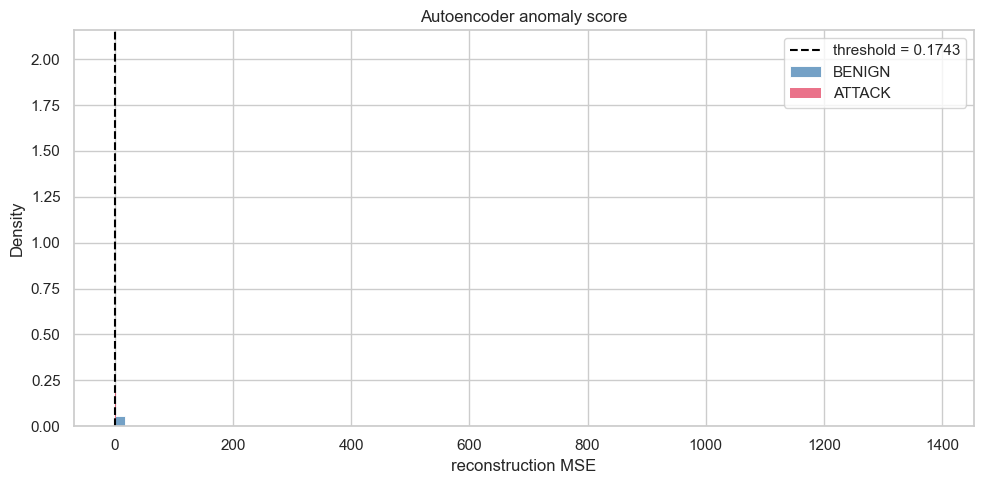

In [6]:
val_attack = val[val[cfg.LABEL_COL] != "BENIGN"]
X_val_attack = scaler.transform(val_attack[feature_names].astype(np.float32).values)
err_attack_val = reconstruction_error(ae, X_val_attack)

plt.figure(figsize=(10, 5))
sns.histplot(err_benign_val, bins=80, color="steelblue", label="BENIGN", stat="density")
sns.histplot(err_attack_val, bins=80, color="crimson",  label="ATTACK", stat="density",
             alpha=0.6)
plt.axvline(threshold, color="black", ls="--", label=f"threshold = {threshold:.4f}")
plt.xlabel("reconstruction MSE"); plt.title("Autoencoder anomaly score")
plt.legend(); plt.tight_layout(); plt.show()


## 5b. Quality metrics — AUC, separation, per-class detection rate

Histogram tells the visual story. These numbers tell us *quantitatively*
how usable the AE is as an anomaly detector.


In [7]:
from sklearn.metrics import roc_auc_score
from src.evaluation import autoencoder_anomaly_metrics

# Reconstruction error on full validation set (already computed pieces above).
err_all = np.concatenate([err_benign_val, err_attack_val])
y_all   = np.concatenate([np.zeros(len(err_benign_val)),
                          np.ones (len(err_attack_val))])

print("=" * 60)
print("OVERALL AE QUALITY")
print("=" * 60)
auc = roc_auc_score(y_all, err_all)
print(f"ROC-AUC                 : {auc:.4f}    (1.0 = perfect, 0.5 = random)")

stats = autoencoder_anomaly_metrics(err_all, y_all.astype(int), threshold)
for k, v in stats.items():
    line = f"  {k:<10}: {v:.4f}" if isinstance(v, float) else f"  {k:<10}: {v}"
    print(line)

# Separation: median attack error vs threshold
sep = np.median(err_attack_val) / max(threshold, 1e-9)
print(f"\nSeparation (median_attack / threshold): {sep:.2f}x")
print("  > 2x = clean separation, ~1x = AE only marginally useful")


OVERALL AE QUALITY
ROC-AUC                 : 0.7985    (1.0 = perfect, 0.5 = random)
  tp        : 32305
  fp        : 3407
  fn        : 51168
  tn        : 337291
  precision : 0.9046
  recall    : 0.3870
  f1        : 0.5421
  auc       : 0.7985

Separation (median_attack / threshold): 0.15x
  > 2x = clean separation, ~1x = AE only marginally useful


### Per-attack-class detection rate

Tells us *which* attacks the AE catches at the current threshold and which
slip through. A detector with 95% recall on DDoS but 5% on web attacks is
still useful, but you need to know that.


                   class  support  detection_rate  median_err
        DoS Slowhttptest      825        0.933333    0.188267
                DoS Hulk    34518        0.629237    0.610187
           DoS slowloris      870        0.547126    0.562546
           DoS GoldenEye     1544        0.466321    0.155433
                    DDoS    19204        0.446053    0.098842
Web Attack  Brute Force      226        0.044248    0.001766
                     Bot      294        0.023810    0.002354
        Web Attack  XSS       98        0.010204    0.001676
                PortScan    23820        0.001427    0.004506
             SSH-Patator      884        0.001131    0.007494
             FTP-Patator     1190        0.000000    0.013549


C:\Users\diable\AppData\Local\Temp\ipykernel_11456\424179712.py:25: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
d:\smart_ids\ids_pfa\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


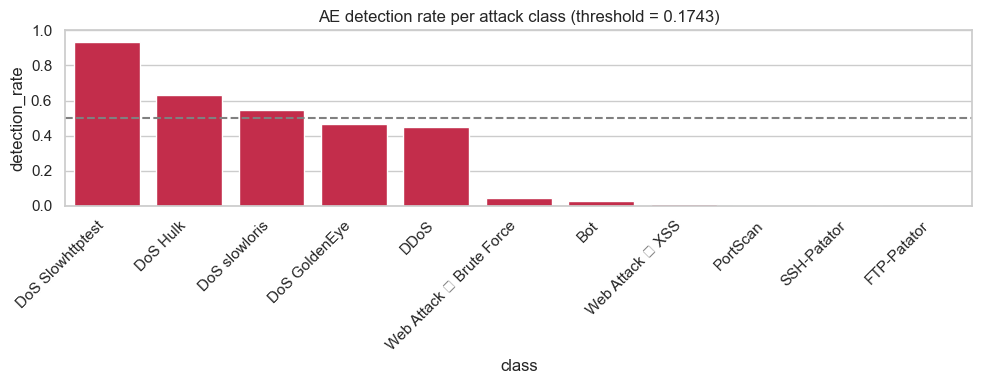

In [8]:
val_attack_labels = val.loc[val[cfg.LABEL_COL] != "BENIGN", cfg.LABEL_COL].values

per_class = []
for cls in np.unique(val_attack_labels):
    mask = val_attack_labels == cls
    errs = err_attack_val[mask]
    detected = (errs > threshold).sum()
    per_class.append({
        "class":         cls,
        "support":       int(mask.sum()),
        "detection_rate": detected / max(mask.sum(), 1),
        "median_err":    float(np.median(errs)),
    })

per_class_df = (pd.DataFrame(per_class)
                  .sort_values("detection_rate", ascending=False))
print(per_class_df.to_string(index=False))

plt.figure(figsize=(10, 4))
sns.barplot(data=per_class_df, x="class", y="detection_rate", color="crimson")
plt.axhline(0.5, ls="--", color="gray")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.title(f"AE detection rate per attack class (threshold = {threshold:.4f})")
plt.tight_layout(); plt.show()


### Threshold sweep

The "right" threshold trades false positives against missed attacks. The
sweep below shows how F1, precision, and recall behave at different benign
percentiles. Pick whichever percentile gives the highest F1 — and update
`cfg.AE_CONFIG["threshold_percentile"]` accordingly.


In [9]:
percentiles = [90, 95, 97, 99, 99.5, 99.9]
sweep = []
for p in percentiles:
    thr = float(np.percentile(err_benign_val, p))
    s = autoencoder_anomaly_metrics(err_all, y_all.astype(int), thr)
    sweep.append({"percentile": p, "threshold": thr,
                  "precision": s["precision"], "recall": s["recall"],
                  "f1": s["f1"], "false_positive_rate": s["fp"] / max(s["fp"]+s["tn"], 1)})
sweep_df = pd.DataFrame(sweep)
print(sweep_df.to_string(index=False))

best = sweep_df.loc[sweep_df["f1"].idxmax()]
print(f"\nBest F1 at percentile P{best['percentile']}: "
      f"threshold={best['threshold']:.4f} (F1={best['f1']:.4f})")

# Use the best percentile from the sweep, not the config default.
threshold = float(best["threshold"])
print(f"\nUsing threshold = {threshold:.4f} for the saved model.")


 percentile  threshold  precision   recall       f1  false_positive_rate
       90.0   0.019225   0.557147 0.513495 0.534431             0.100001
       95.0   0.039813   0.699628 0.475339 0.566076             0.050000
       97.0   0.063682   0.784071 0.444623 0.567458             0.030000
       99.0   0.174251   0.904598 0.387011 0.542098             0.010000
       99.5   0.303112   0.945311 0.352857 0.513892             0.005001
       99.9   0.865924   0.978156 0.182933 0.308223             0.001001

Best F1 at percentile P97.0: threshold=0.0637 (F1=0.5675)

Using threshold = 0.0637 for the saved model.


## 6. Persist autoencoder and threshold

In [10]:
cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
ae.save(cfg.AE_MODEL_FILE)
with open(cfg.AE_THRESHOLD_FILE, "w") as f:
    json.dump({"threshold": threshold,
               "percentile": cfg.AE_CONFIG["threshold_percentile"]}, f, indent=2)

print("Saved AE   ->", cfg.AE_MODEL_FILE)
print("Saved thr  ->", cfg.AE_THRESHOLD_FILE)


Saved AE   -> D:\smart_ids\models\autoencoder_model.keras
Saved thr  -> D:\smart_ids\models\autoencoder_threshold.json
